Peak Hour Electricity Spikes -> Collect hourly meter data from dorms; apply moving average smoothing and linear regression to predict evening peaks based on past week. Visualize trends on a live Plotly dashboard.

In [42]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv('smart_meter_data.csv')

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Timestamp             5000 non-null   object 
 1   Electricity_Consumed  5000 non-null   float64
 2   Temperature           5000 non-null   float64
 3   Humidity              5000 non-null   float64
 4   Wind_Speed            5000 non-null   float64
 5   Avg_Past_Consumption  5000 non-null   float64
 6   Anomaly_Label         5000 non-null   object 
dtypes: float64(5), object(2)
memory usage: 273.6+ KB
None


In [5]:
df['HouseName'] = [ float(i+1) for i in range(len(df))]
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Timestamp             5000 non-null   object 
 1   Electricity_Consumed  5000 non-null   float64
 2   Temperature           5000 non-null   float64
 3   Humidity              5000 non-null   float64
 4   Wind_Speed            5000 non-null   float64
 5   Avg_Past_Consumption  5000 non-null   float64
 6   Anomaly_Label         5000 non-null   object 
 7   HouseName             5000 non-null   float64
dtypes: float64(6), object(2)
memory usage: 312.6+ KB
None


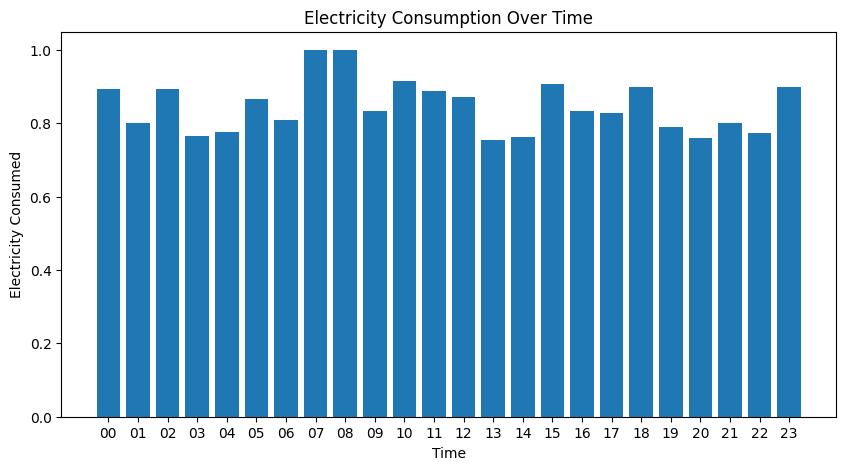

In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Time'] = df['Timestamp'].dt.strftime('%H')
plt.figure(figsize=(10, 5))
plt.bar(df['Time'], df['Electricity_Consumed'])


plt.xlabel("Time")
plt.ylabel("Electricity Consumed")
plt.title("Electricity Consumption Over Time")


plt.show()


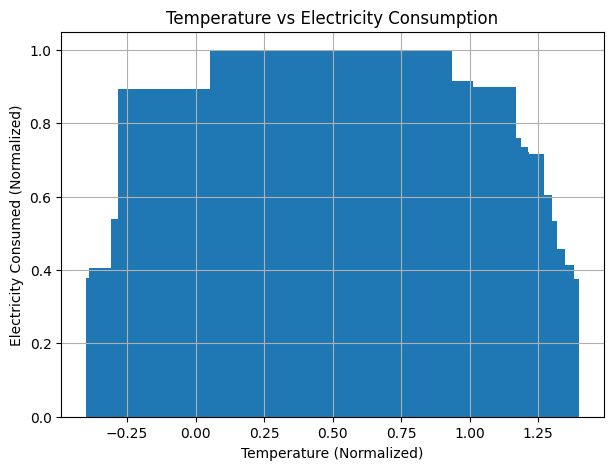

In [ ]:
x = df['Temperature']
y = df['Electricity_Consumed']



plt.figure(figsize=(7,5))
plt.bar(x, y)


plt.xlabel("Temperature (Normalized)")
plt.ylabel("Electricity Consumed (Normalized)")
plt.title("Temperature vs Electricity Consumption")
plt.grid(True)

plt.show()


In [36]:
df = df.sort_values('Timestamp')

df['Hour'] = df['Timestamp'].dt.hour
df['MA_Electricity'] = df['Electricity_Consumed'].rolling(window=24).mean()
df = df.dropna()


In [44]:
X = df[['Hour',
        'Temperature',
        'Humidity',
        'Wind_Speed',
        'MA_Electricity']]

y = df['Electricity_Consumed']

#makes the model trend-aware

In [45]:
model = LinearRegression()
model.fit(X,Y)

LinearRegression()

In [47]:
prediction = model.predict([[19, 0.65, 0.55, 0.40, df['MA_Electricity'].iloc[-1]]])

print("Predicted Electricity:", prediction[0])


Predicted Electricity: 0.4181793497898592


C:\Users\sushm\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [48]:
y_pred = model.predict(X)
print("R2 Score : ", r2_score(Y,y_pred))


R2 Score :  0.0425391169852638


In [49]:
import joblib
joblib.dump(model, "Elec_model.pkl")
print("Model Saved")

Model Saved


In [ ]:

import joblib
import plotly.graph_objects as go

# Load trained model
model = joblib.load("Elec_model.pkl")

# Scale prediction to 1–10
def scale_to_1_10(pred):
    return round(1 + 9 * pred, 2)

# Prediction function
def predict_electricity(hour, temp, humid, wind, ma_value):
    pred = model.predict([[hour, temp, humid, wind, ma_value]])[0]
    scaled = scale_to_1_10(pred)
    return pred, scaled

# Plotly gauge
def show_gauge(value):
    fig = go.Figure(go.Indicator(
        mode="gauge+number",
        value=value,
        title={'text': "Electricity Consumption Level (1–10)"},
        gauge={
            'axis': {'range': [1, 10]},
            'steps': [
                {'range': [1, 3], 'color': "lightgreen"},
                {'range': [3, 6], 'color': "yellow"},
                {'range': [6, 10], 'color': "red"}
            ]
        }
    ))
    fig.show()

# ---- Example Input (Change these values) ----
hour = 4       # 7 PM
temp = 0.90
humid = 0.40
wind = 0.40
ma_value = 0.60

# Predict
pred, scaled = predict_electricity(hour, temp, humid, wind, ma_value)

print("Normalized Prediction:", pred)
print("Scaled Output (1–10):", scaled)

# Show dashboard gauge
show_gauge(scaled)


Normalized Prediction: 0.6027002402306424
Scaled Output (1–10): 6.42


C:\Users\sushm\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

